# Presentación 

## Procesamiento de datos (dataset)

In [1]:
import pandas 
import matplotlib.pyplot as plt
import seaborn as sns

### Lectura del dataset

In [3]:
df_walmart = pandas.read_csv("data_input/Walmart_Sales.csv")

### Descripción de los datos

#### Composición general

In [ ]:
# Composición del DataFrame (columnas, tipos de datos, valores nulos, etc.)
df_walmart.info()

In [ ]:
# Primeras filas del DataFrame (con sus valores)
df_walmart.head(5)

In [ ]:
# Resumen estadistico

# Para formatear decimales
pandas.options.display.float_format = '{:.2f}'.format

medidas_resumen = df_walmart.describe()
df_medidas_resumen = pandas.DataFrame(medidas_resumen)
print(df_medidas_resumen)

# Para exportar el DataFrame a un archivo Excel, descomentar la siguiente línea:

#df_medidas_resumen.to_excel('data_output/df_medidas_resumen.xlsx', index=True, sheet_name='Hoja1')

Los datos contienen 8 columnas y 6435 filas y no posee datos NULL.

| Columna      | Tipo de dato                           | Descripción |
| ------------ | -------------------------------------- | ----------- |
| Store        | Número de tienda                       | int64       |
| Date         | Fecha de inicio de la semana de ventas | object      |
| Weekly_Sales | Ventas semanales                       | float64     |
| Holiday_Flag | Presencia o ausencia de día festivo    | int64       |
| Temperature  | Temperatura del aire en la región      | float64     |
| Fuel_Price   | Costo del combustible en la región     | float64     |
| CPI          | Índice de precios al consumidor        | float64     |
| Unemployment | Tasa de desempleo                      | float 64    |

#### Composición | Análisis por variable

##### 1) Store

In [ ]:
# ¿Cuales son las tiendas registradas?
store_x = df_walmart["Store"].unique() # valores de la variable (categorías)

# ¿Cual es su frecuencia absoluta?
store_fa = df_walmart["Store"].value_counts() # cantidad de registros por categoría

print(store_x,store_fa)

##### 2) Date

El período registrado en el DataFrame va desde 2010-02-05 00:00:00 hasta 2012-10-26 00:00:00.
Con un total de 6435 registros, el acumulado por mes/año es:
anio_mes
2010-02    180
2010-03    180
2010-04    225
2010-05    180
2010-06    180
2010-07    225
2010-08    180
2010-09    180
2010-10    225
2010-11    180
2010-12    225
2011-01    180
2011-02    180
2011-03    180
2011-04    225
2011-05    180
2011-06    180
2011-07    225
2011-08    180
2011-09    225
2011-10    180
2011-11    180
2011-12    225
2012-01    180
2012-02    180
2012-03    225
2012-04    180
2012-05    180
2012-06    225
2012-07    180
2012-08    225
2012-09    180
2012-10    180
Freq: M, dtype: int64


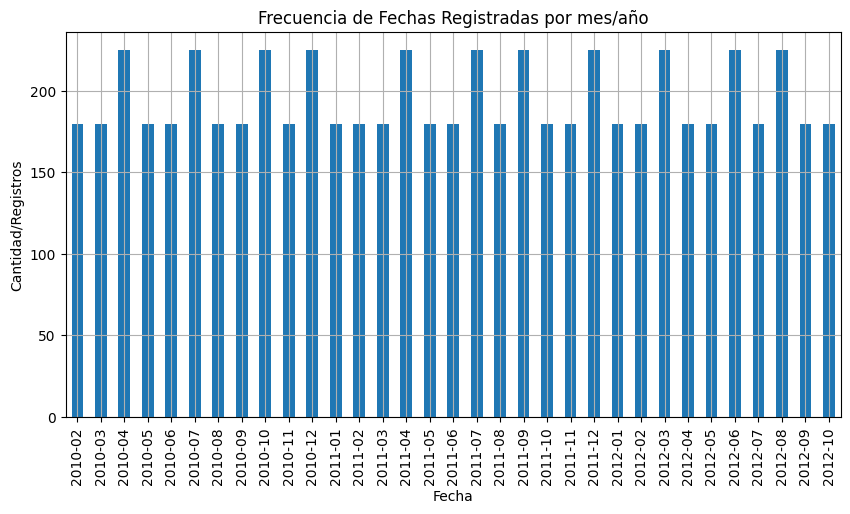

In [ ]:
# ¿Cual es el período registrado en el DataFrame?
 
# Formateo de datos
colum_date = df_walmart["Date"] # selecciono la columna 
formato_date = pandas.to_datetime(colum_date, format='%d-%m-%Y') #convierto la columna a formato datetime

# Obtener período registrado
periodo = formato_date.min(), formato_date.max()
print(f"El período registrado en el DataFrame va desde {periodo[0]} hasta {periodo[1]}.")


## ¿Cuál es la frecuencia de fechas registradas?

# Datos
data = formato_date #fecha formateada
df = pandas.DataFrame(data) # creo un nuevo dataframe
df['anio_mes'] = df['Date'].dt.to_period('M') # crea variable por mes/año
mm_aa = df['anio_mes'].unique() # valores de la variable (categorías)

# Agrupar y contar (size() cuenta las filas por grupos (anio_mes)
conteo = df.groupby('anio_mes').size()

# Chequear total registros
conteototal = conteo.sum()
print(f"Con un total de {conteototal} registros, el acumulado por mes/año es:")
print(conteo)


# Visualizar (Gráfico de barras)
conteo.plot(kind='bar', figsize=(10, 5)) #se lo aplico a la variable "conteo" que ya posee las categorías y valores a graficar.
plt.title('Frecuencia de Fechas Registradas por mes/año')
plt.ylabel('Cantidad/Registros')
plt.xlabel('Fecha')
plt.grid(True)
plt.show()


Se puede observar que hay períodos que tienen más cantidad de registros y una regularidad en la diferencia de 45 registros. Para poder trabajar con esta variable, se asume que la diferencia no distorciona los datos asociados a cada período.  

##### 3) Temperature

La temperatura máxima es 100.14 grados Fahrenheit o 37.86 grados Celsius.
La temperatura mínima es -2.06 grados Fahrenheit o -18.92 grados Celsius.


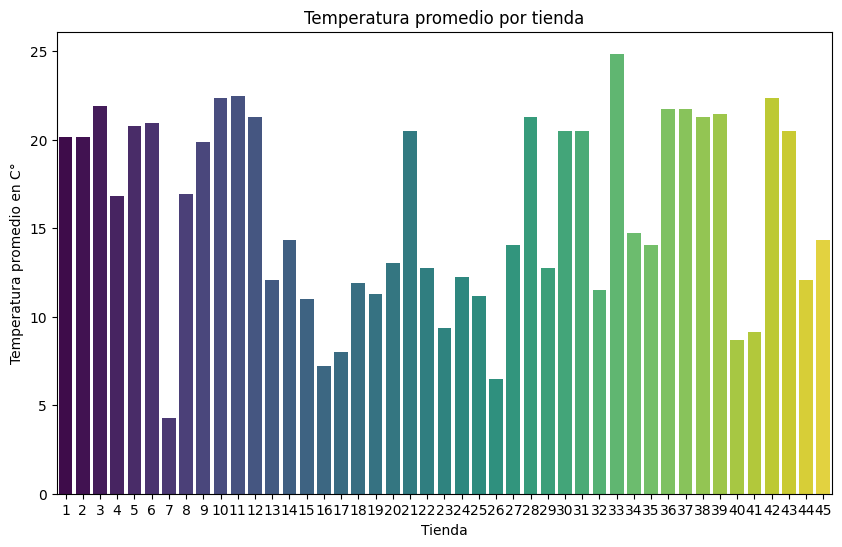

In [6]:
# ¿Cuál es la temperatura máxima y minima registrada?

# Agregar columna de temperatura en grados Celsius para trabajar con un mismo DataFrame.
# Fórmula: (Fahrenheit - 32) * 5/9 o (Fahrenheit - 32) / 1.8
df_walmart['Celsius'] = ((df_walmart['Temperature'] - 32) / 1.8).round(2) # redondea a 2 decimales.

print(f"La temperatura máxima es {df_walmart['Temperature'].max()} grados Fahrenheit o {df_walmart['Celsius'].max()} grados Celsius.")
print(f"La temperatura mínima es {df_walmart['Temperature'].min()} grados Fahrenheit o {df_walmart['Celsius'].min()} grados Celsius.")

# Gráfico
temp_promedio = df_walmart.groupby("Store")["Celsius"].mean().reset_index() #promedio de temperatura por tienda. Selecciono la variable "Celsius" del dataframe "df_temperature" y la agrupo por tienda, luego calculo el promedio con mean()

plt.figure(figsize=(10,6))
sns.barplot(data= temp_promedio, x="Store", y="Celsius", hue="Store", palette="viridis", legend=False)
plt.title("Temperatura promedio por tienda")
plt.xlabel("Tienda")
plt.ylabel("Temperatura promedio en C°")

# Mostrar 
plt.show()

Si bien se desconoce la ubicación geográfica de cada tienda, dada la diferencia de amplitud promedio, se asume que están distribuidas por todo el pais (en lugar de un solo distrito o estado). Por ejemplo, a menor promedio se puede inferir que se ubican más al norte de EE.UU y a mayor promedio al sur. Teniendo en cuenta que el criterio de "frío" o "cálido" a cada punto del pais es relativo, para analizar cómo inside la temperatura en las ventas, la ubicación geográfica de cada una es relevante. 

##### 4) Día Festivo

Los valores del día festivo se representan con 1 y 0: 1 para indicar verdadero y 0 para indicar falso. Por lo tanto, el 1 significa la presencia de un día festivo y el 0 su ausencia.

## Análisis de los datos

#### Variación de ventas a lo largo del período

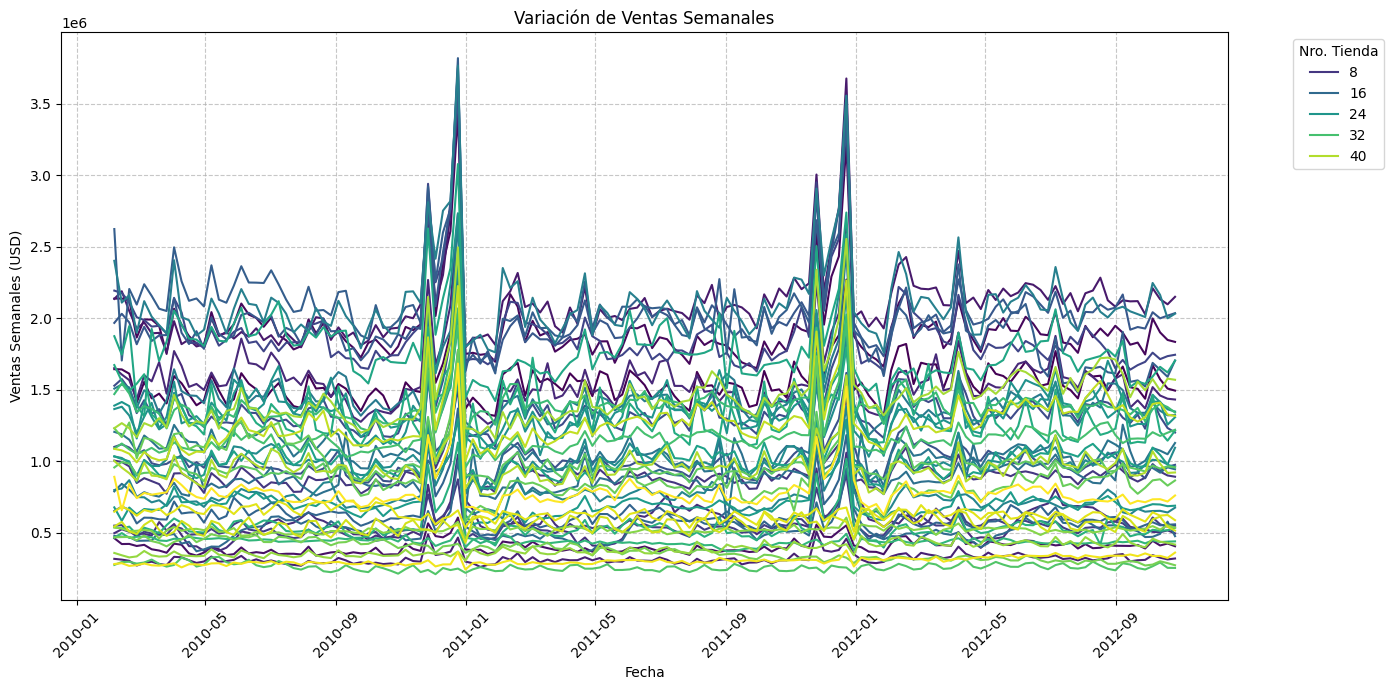

In [8]:
# Convertir la columna 'Date' a datetime
df_walmart['Date'] = pandas.to_datetime(df_walmart['Date'], format='%d-%m-%Y')
# Ordena todo el dataset por fecha
df_walmart = df_walmart.sort_values('Date')

# Graficar con Seaborn/Matplotlib
plt.figure(figsize=(14, 7)) # Tamaño del lienzo
sns.lineplot(data=df_walmart,
              x='Date',
              y='Weekly_Sales',
              hue='Store', # agrupe los datos por el número de tienda 
              palette='viridis', # le asigna un color distinto a cada tienda
              linewidth=1.5 ) 

# Personalizar el gráfico
plt.title('Variación de Ventas Semanales')
plt.xlabel('Fecha')
plt.ylabel('Ventas Semanales (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotar fechas para mejor lectura
plt.legend(title='Nro. Tienda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Mostrar gráfico
plt.show()

A lo largo del período registrado, se puede observar una tendencia a mayores ventas en los meses de diciembre.

#### Variación de ventas en diciembre por tienda

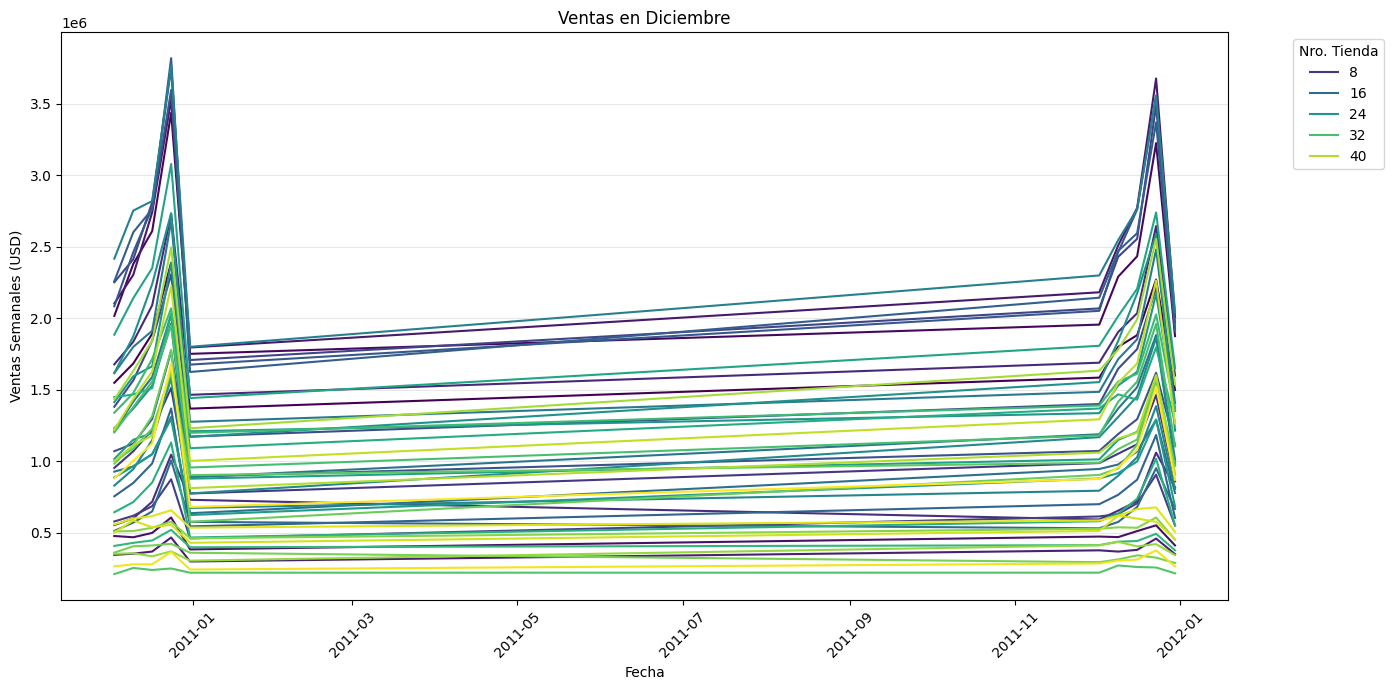

In [9]:
# Convertir la columna 'Date' a datetime
df_walmart['Date'] = pandas.to_datetime(df_walmart['Date'], format='%d-%m-%Y')
# Ordena todo el dataset por fecha
df_walmart = df_walmart.sort_values('Date')
# Filtrar fechas por mes de diciembre
df_diciembre = df_walmart[df_walmart['Date'].dt.month == 12]

# Graficar con Seaborn/Matplotlib
plt.figure(figsize=(14, 7)) # Tamaño del lienzo
sns.lineplot(data=df_diciembre,
              x='Date',
              y='Weekly_Sales',
              hue='Store', # agrupe los datos por el número de tienda 
              palette='viridis', # le asigna un color distinto a cada tienda
              linewidth=1.5 ) 

# Personalizar el gráfico
plt.title('Ventas en Diciembre')
plt.xlabel('Fecha')
plt.ylabel('Ventas Semanales (USD)')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45) # Rotar fechas para mejor lectura
plt.legend(title='Nro. Tienda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Mostrar gráfico
plt.show()

Al analizar la variación por tienda en los meses de diciembre se puede observar más claramente que no en todas se produce un marcado incremento. 

#### Variación de ventas en diciembre por tiendas seleccionadas

In [ ]:
# Identificar las tiendas con mayor y menor venta total histórica
ventas_por_tienda = df_walmart.groupby('Store')['Weekly_Sales'].sum()
tienda_top = ventas_por_tienda.idxmax()
tienda_bottom = ventas_por_tienda.idxmin()

# Convertir la columna 'Date' a datetime
df_walmart['Date'] = pandas.to_datetime(df_walmart['Date'], format='%d-%m-%Y')
# Ordena todo el dataset por fecha
df_walmart = df_walmart.sort_values('Date')
# Filtrar fechas por mes de diciembre
df_diciembre = df_walmart[df_walmart['Date'].dt.month == 12]

# Filtrar el dataframe de diciembre para esas dos tiendas
df_comparativa = df_diciembre[df_diciembre['Store'].isin([tienda_top, tienda_bottom])]

print(f"La tienda con mayores ventas es la {tienda_top} y la de menores ventas es la {tienda_bottom}.")

# Graficar la comparativa
plt.figure(figsize=(14, 7))

# Líneas para la tendencia (una para la mejor y otra para la peor)
sns.lineplot(data=df_comparativa, x='Date', y='Weekly_Sales', 
             hue='Store', palette=['#2ecc71', '#e74c3c'], linewidth=2)

# Puntos para resaltar los festivos 
sns.scatterplot(data=df_comparativa,
                x='Date',
                y='Weekly_Sales', 
                hue='Holiday_Flag',
                size='Holiday_Flag', 
                sizes={0:50, 1:200}, # tamaño de los puntos : si no es festivo(0)=50, si es festivo(1)=200
                size_order=[0, 1], # fuerza el orden de los tamaños: 0=no festivo, 1=festivo
                palette='coolwarm',
            
                legend=True)

plt.title(f'Contraste de Ventas en Diciembre: Tienda {tienda_top} (Máx) vs Tienda {tienda_bottom} (Mín)')
plt.legend(title='Nro. de tienda/\n 1=Día festivo', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True, alpha=0.3)
plt.tight_layout() # ajusta automaticamente los margenes del gráfico
plt.show()

La variación en los meses de diciembre se debe a la Navidad (día festivo). Pero cuando comparamos las tiendas con mayor y menor volumen de venta, este factor no influye de igual manera. 

#### Ventas totales por tienda

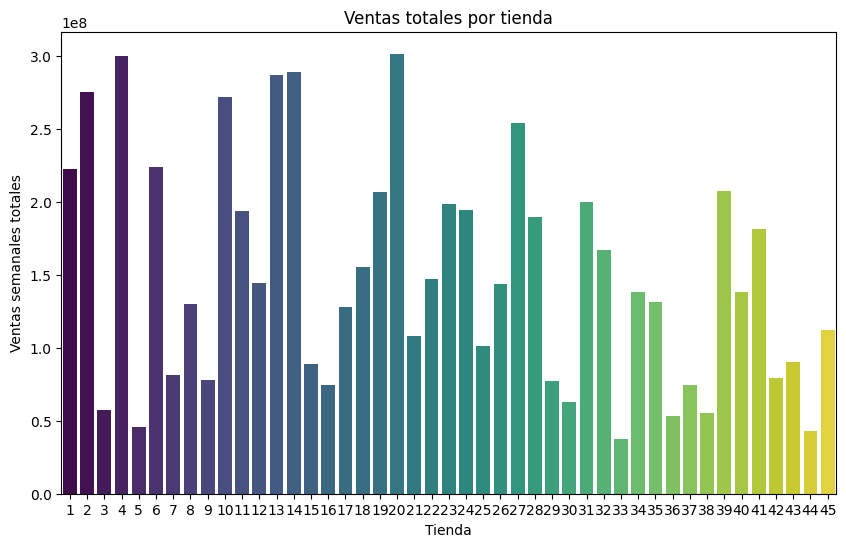

In [ ]:
# Formato de números decimales
pandas.options.display.float_format = '{:.2f}'.format

# Agrupar ventas por tienda
sales_by_store = df_walmart.groupby("Store")['Weekly_Sales'].sum() # 1)agrupa por tienda, 2) suma las ventas semanales por tienda
df_sales_by_store = pandas.DataFrame(sales_by_store).reset_index()

#Crear grafico de barras
x = df_sales_by_store['Store'].values # se asume variable independiente
y = df_sales_by_store['Weekly_Sales'].values # se asume variable dependiente

plt.figure(figsize=(10,6))
sns.barplot(x=x, y=y, hue=x, palette="viridis", legend=False)
plt.title("Ventas totales por tienda")
plt.xlabel("Tienda")
plt.ylabel("Ventas semanales totales")

# Mostrar 
plt.show()

Se identifica el volumen de venta de cada tienda, permitiendo observar rápidamente cuáles son las de mayor o menor ingreso y la heterogeneidad entre ellas.  

## Conclusiones

El análisis exploratorio permite describir los datos, a partir de los cuales se investiga qué factores influyen en las ventas de la empresa "Walmart". 

De forma general, se puede observar que la Navidad tiene incidencias significativas en el volumen de venta de las tiendas con mayor promedio de ingresos.